In [1]:
# Imports for plotting

import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np
import seaborn as sns

sns.set_style("darkgrid")

Field profiles are defined as functions of time. A base `rabi_freq` is multiplied by a time function `rabi_freq_t_func` and related arguments `rabi_freq_t_args`. For example, a Gaussian pulse with a peak of  $\Omega_0 = 2\pi \cdot 0.001 \mathrm{~ MHz}$ and a full-width at half-maximum (FWHM) of $1 \mathrm{~ \mu s}$ arriving at the start of the medium at $t = 0 \mathrm{~ \mu s}$ can be specified in JSON with `"rabi_freq": 1.0e-3`, `"rabi_freq_t_func": "gaussian", ` and `"rabi_freq_t_args": {"ampl": 1.0, "centre": 0.0, "fwhm": 1.0}`.

Here we'll show all of the built-in `t_funcs` you can use. It is also possible to write your own.

In [2]:
from maxwellbloch import t_funcs

tlist = np.linspace(0.0, 1.0, 201)

## Gaussian

The Gaussian profile is defined as

$$
\Omega_0 \exp \left[ -4 \log 2 \left( \frac{t - t_0}{t_w}
\right)^2 \right]
$$

where $t_0$ (`centre`) is the point at which the function reaches its peak amplitude
$\Omega_0$ (`ampl`). The width $t_w$ (`fwhm`) is
the full width at half maximum (FWHM) of a Gaussian.

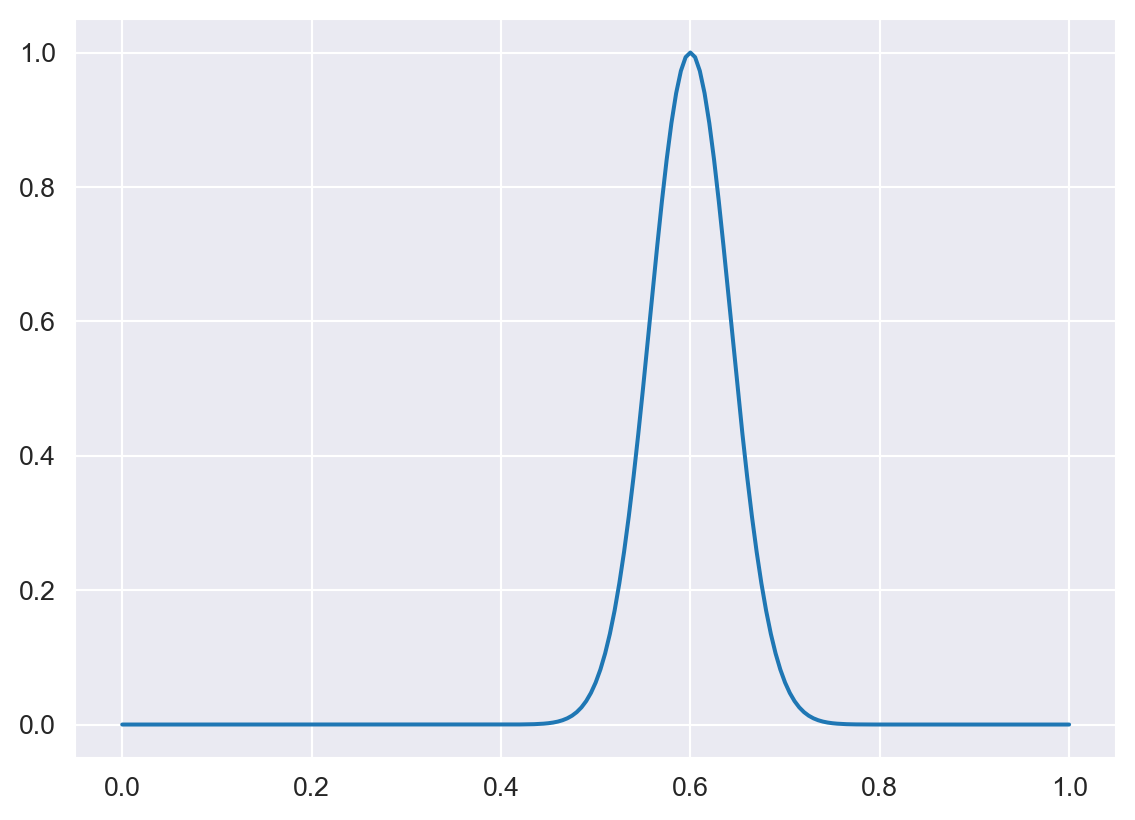

In [3]:
plt.plot(
    tlist,
    t_funcs.gaussian(1)(tlist, args={"ampl_1": 1.0, "fwhm_1": 0.1, "centre_1": 0.6}),
);

### Note

Why are these args written like `ampl_1` here instead of `ampl`? In the `t_funcs` module, each built-in time profile is specified in a [functor][wiki_functor] that takes an index as argument and returns a function whose `t_args` are suffixed with that index. This is because when we have multiple fields, MaxwellBloch needs to be able to distinguish the arguments of each function. When specifying MaxwellBloch problems, you won't need to worry about this.

[wiki_functor]: https://en.wikipedia.org/wiki/Function_object

## Square

The square profile just needs an amplitude `ampl` and switch `on` and `off` times.

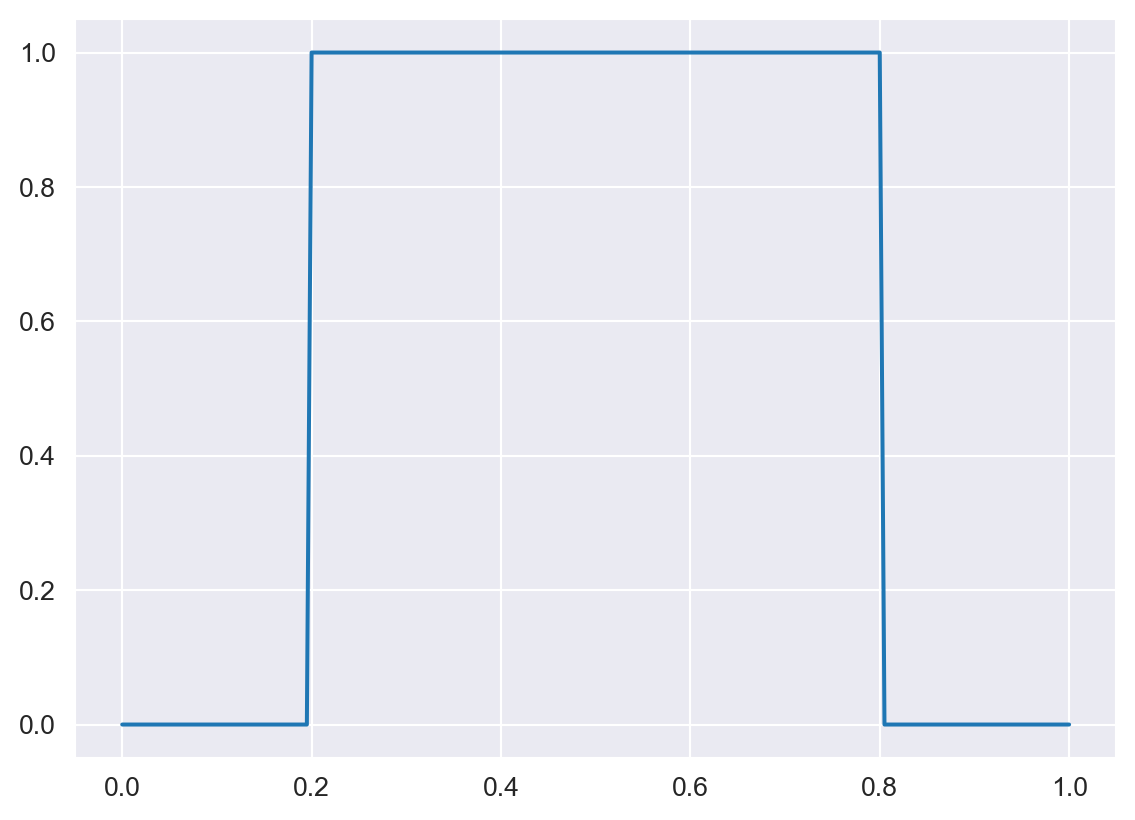

In [4]:
plt.plot(
    tlist, t_funcs.square(1)(tlist, args={"ampl_1": 1.0, "on_1": 0.2, "off_1": 0.8})
);

## Ramp On

The ramp on and off functions use a Gaussian profile to reach peak amplitude. For example, the `ramp_on` function is

$$
\Omega(t) = 
\begin{cases}
\Omega_0 \exp \left[ -4 \log 2 \left( \frac{t - t_0}{t_w}
\right)^2 \right] & t < t_0\\
\Omega_0 & t \ge t_0
\end{cases}
$$
    
where $t_0$ (`centre_1`) is the point at which the function reaches its peak amplitude
$\Omega_0$ (`ampl_1`). The duration of the ramp-on is governed by $t_w$ (`fwhm_1`), which is
the full width at half maximum (FWHM) of a Gaussian. The `ramp_off`, `ramp_onoff` and `ramp_offon` functions behave in the same way.

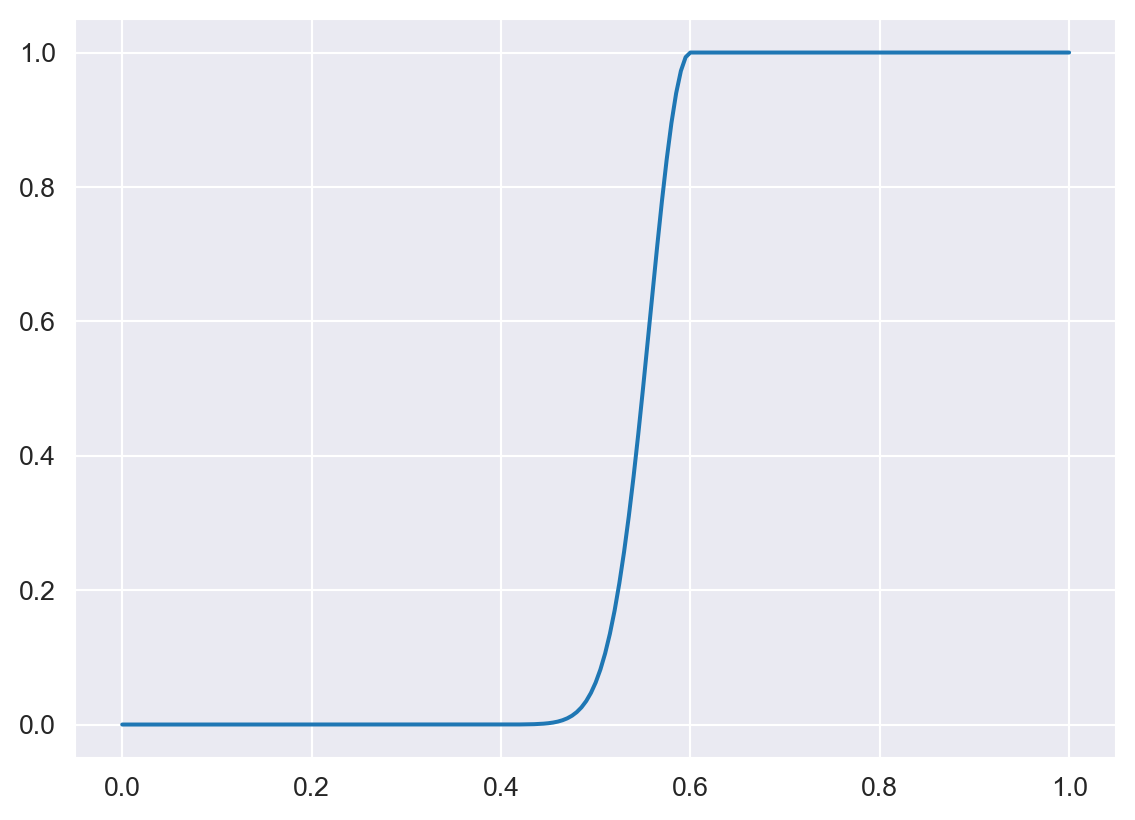

In [5]:
plt.plot(
    tlist, t_funcs.ramp_on(1)(tlist, args={"ampl_1": 1.0, "fwhm_1": 0.1, "on_1": 0.6})
);

## Ramp Off

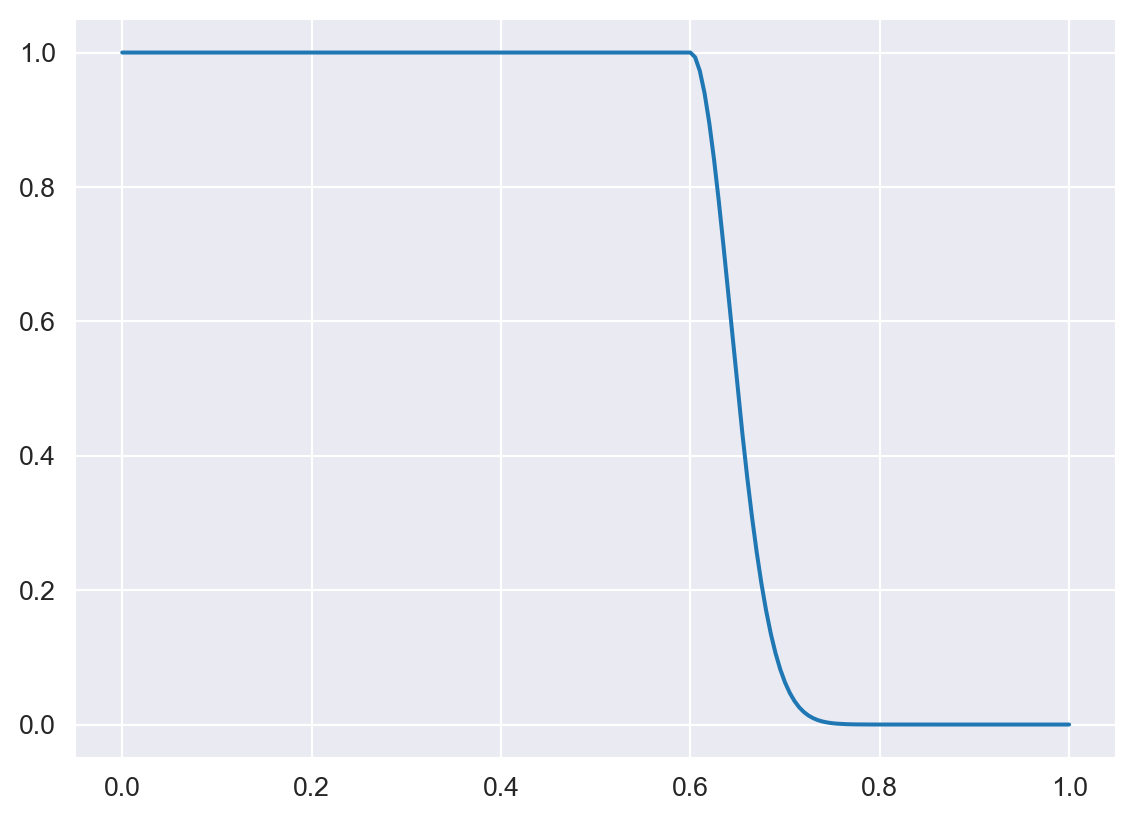

In [6]:
plt.plot(
    tlist, t_funcs.ramp_off(1)(tlist, args={"ampl_1": 1.0, "fwhm_1": 0.1, "off_1": 0.6})
);

## Ramp On and Off

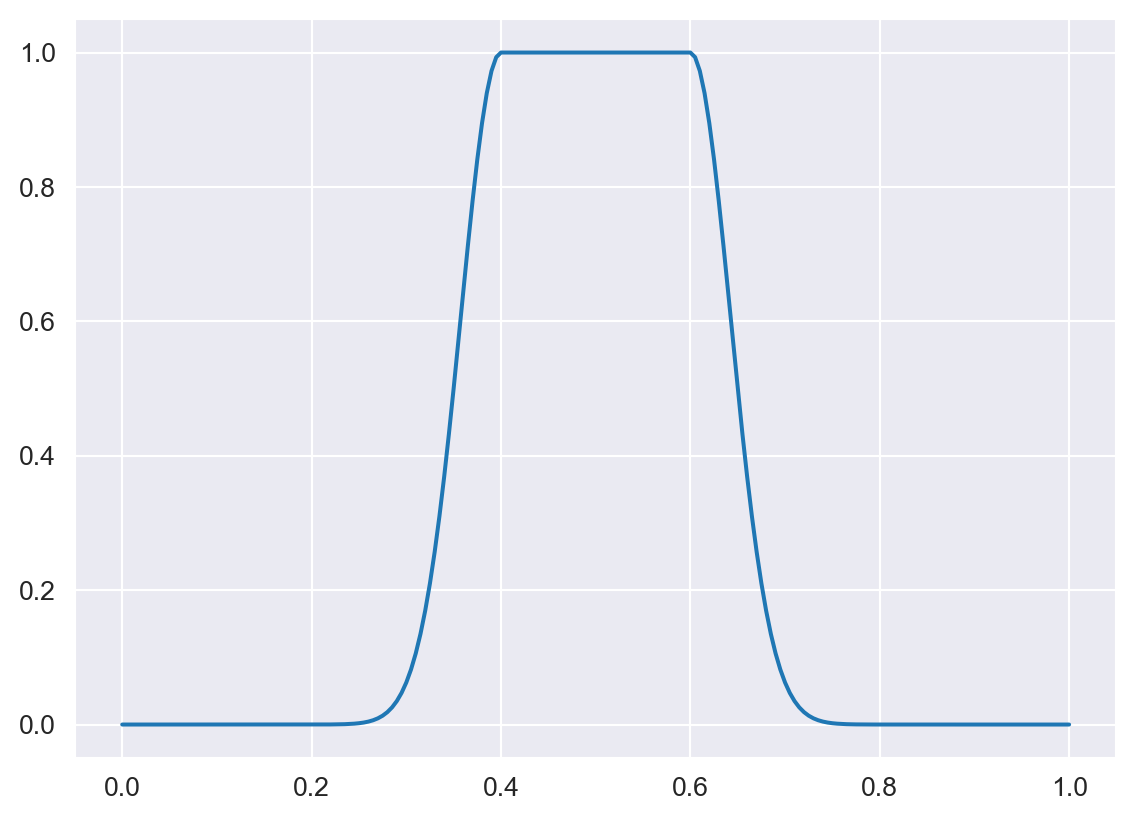

In [7]:
plt.plot(
    tlist,
    t_funcs.ramp_onoff(1)(
        tlist, args={"ampl_1": 1.0, "fwhm_1": 0.1, "on_1": 0.4, "off_1": 0.6}
    ),
);

## Ramp Off and On

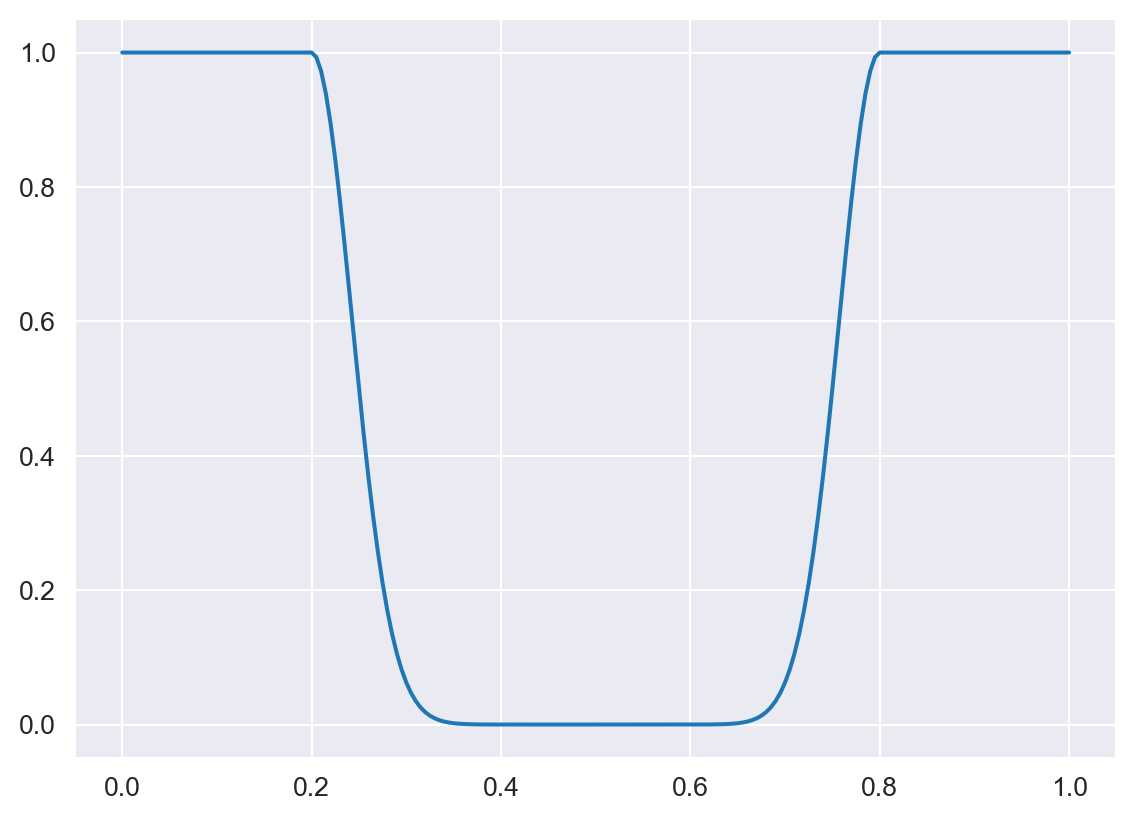

In [8]:
plt.plot(
    tlist,
    t_funcs.ramp_offon(1)(
        tlist, args={"ampl_1": 1.0, "fwhm_1": 0.1, "off_1": 0.2, "on_1": 0.8}
    ),
);

## Sech


The hyperbolic secant (sech) function is defined by

$$
\Omega_0 \textrm{sech}\left(\frac{t - t_0}{t_w}\right)
$$

where $t_0$ (`centre_1`) is the point at which the function reaches its peak amplitude
$\Omega_0$ (`ampl_1`). The width is governed by $t_w$ (`width_1`).

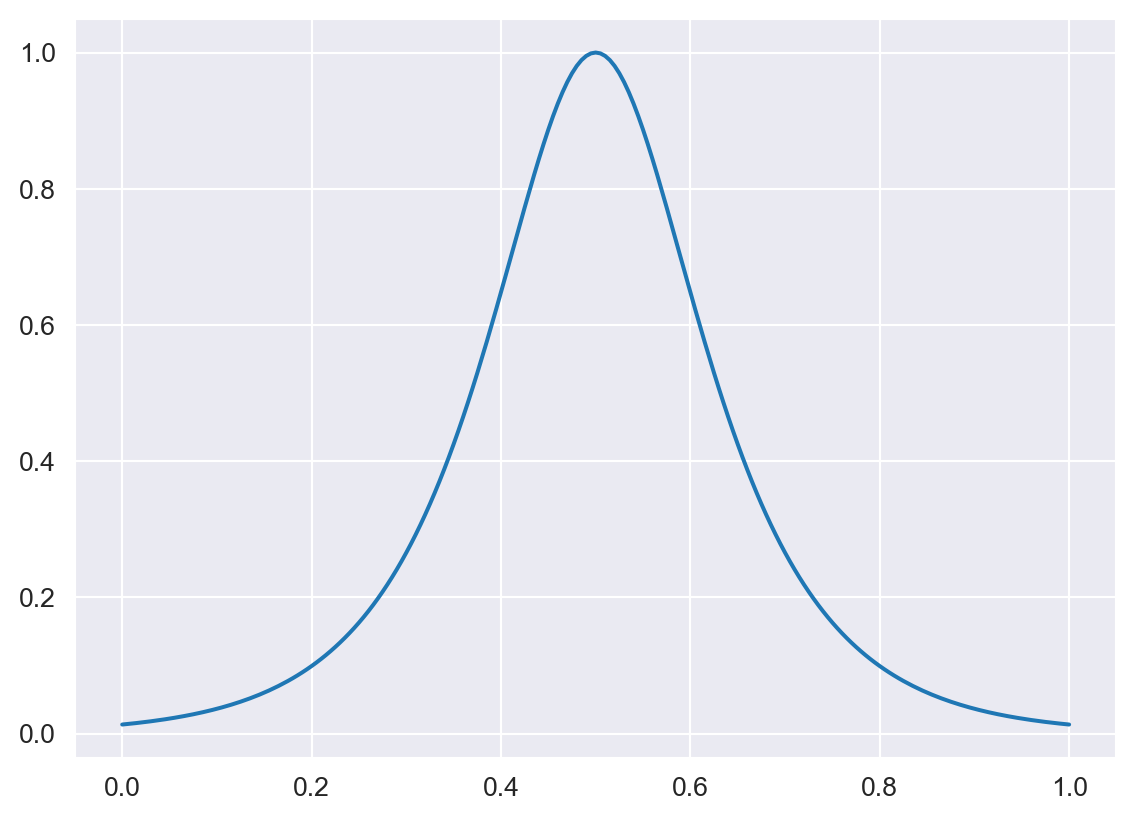

In [9]:
plt.plot(
    tlist, t_funcs.sech(1)(tlist, args={"ampl_1": 1.0, "width_1": 0.1, "centre_1": 0.5})
);

## Sinc

The cardinal sine (sinc) function is defined by

$$
\Omega_0 \textrm{sinc} \left( \frac{w t}{\sqrt{\pi/2}} \right)
$$

where $w$ is a width function and $\Omega_0$ (`ampl_1`) is the peak amplitude of the function.

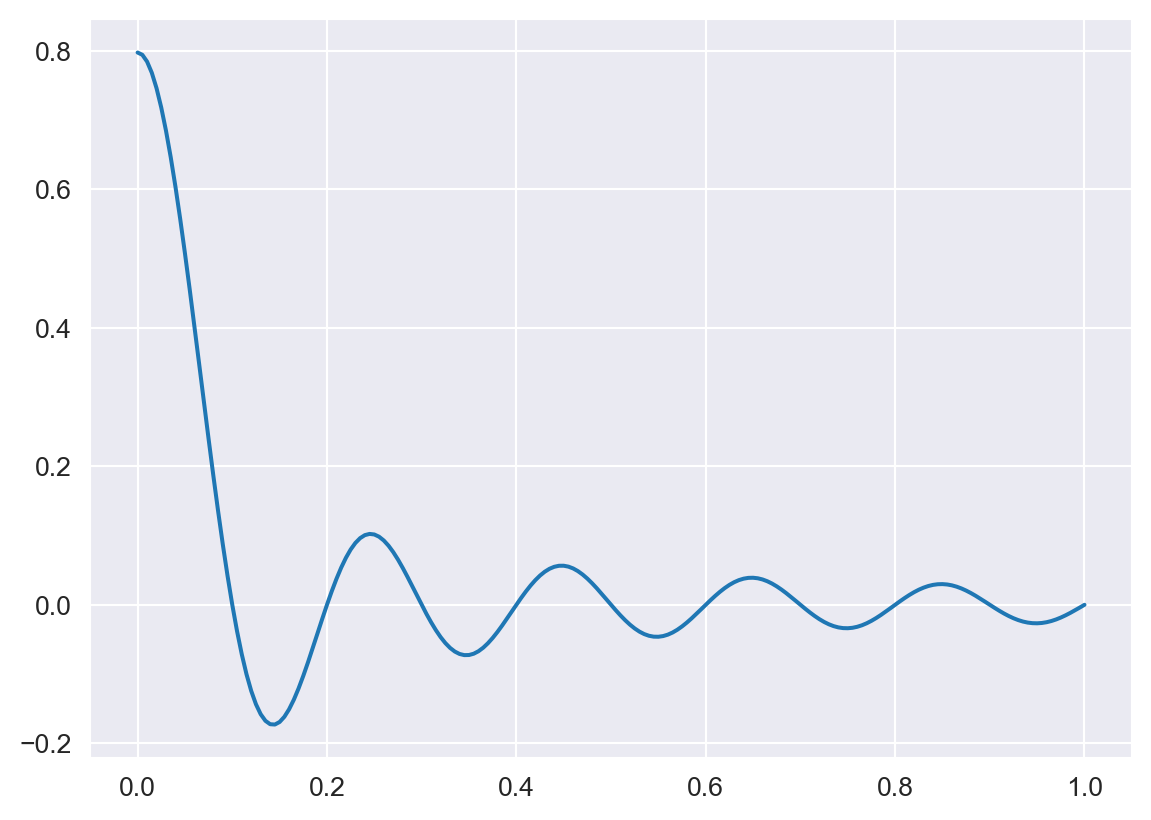

In [10]:
plt.plot(tlist, t_funcs.sinc(1)(tlist, args={"ampl_1": 1.0, "width_1": 10.0}));

## Combining Time Functions

It is possible to create your own time functions, or combine the built-in time functions. To do this you have to pass the function into the Field object directly, it's not possible to specify in JSON.

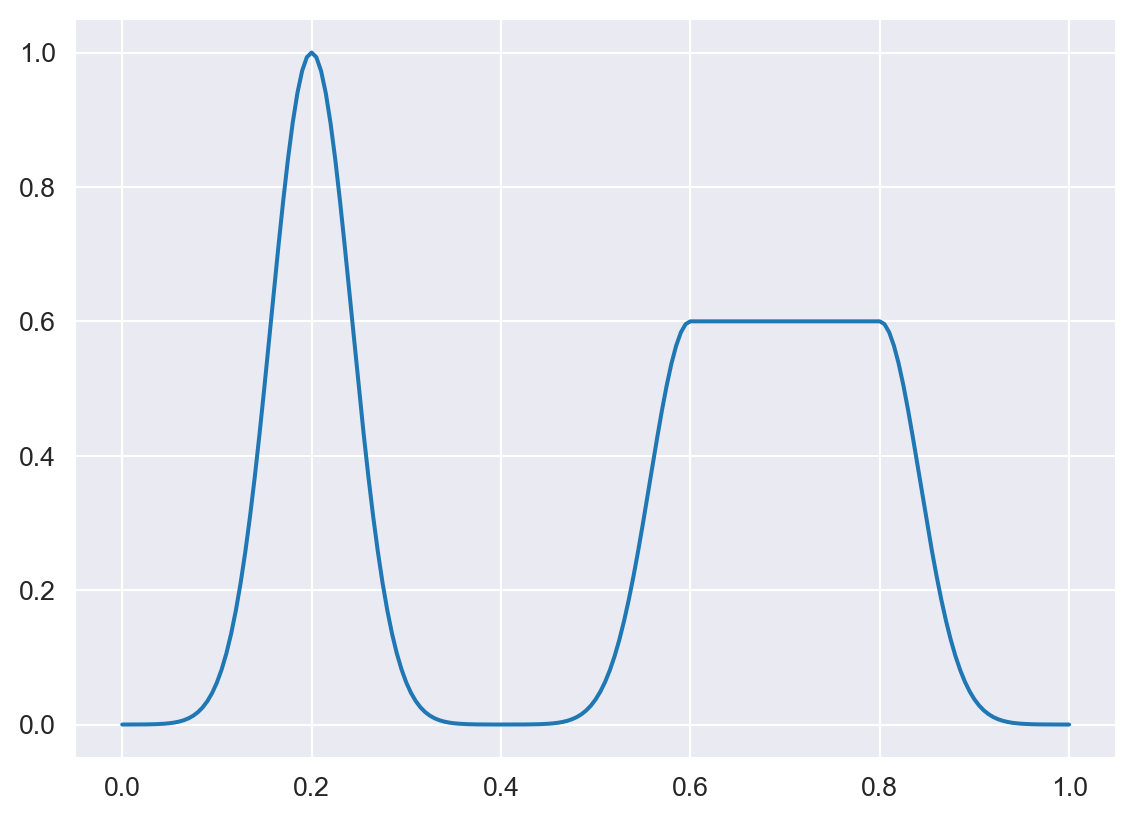

In [11]:
f = lambda t, args: t_funcs.gaussian(1)(t, args) + t_funcs.ramp_onoff(2)(t, args)
plt.plot(
    tlist,
    f(
        tlist,
        args={
            "ampl_1": 1.0,
            "fwhm_1": 0.1,
            "centre_1": 0.2,
            "ampl_2": 0.6,
            "fwhm_2": 0.1,
            "on_2": 0.6,
            "off_2": 0.8,
        },
    ),
);

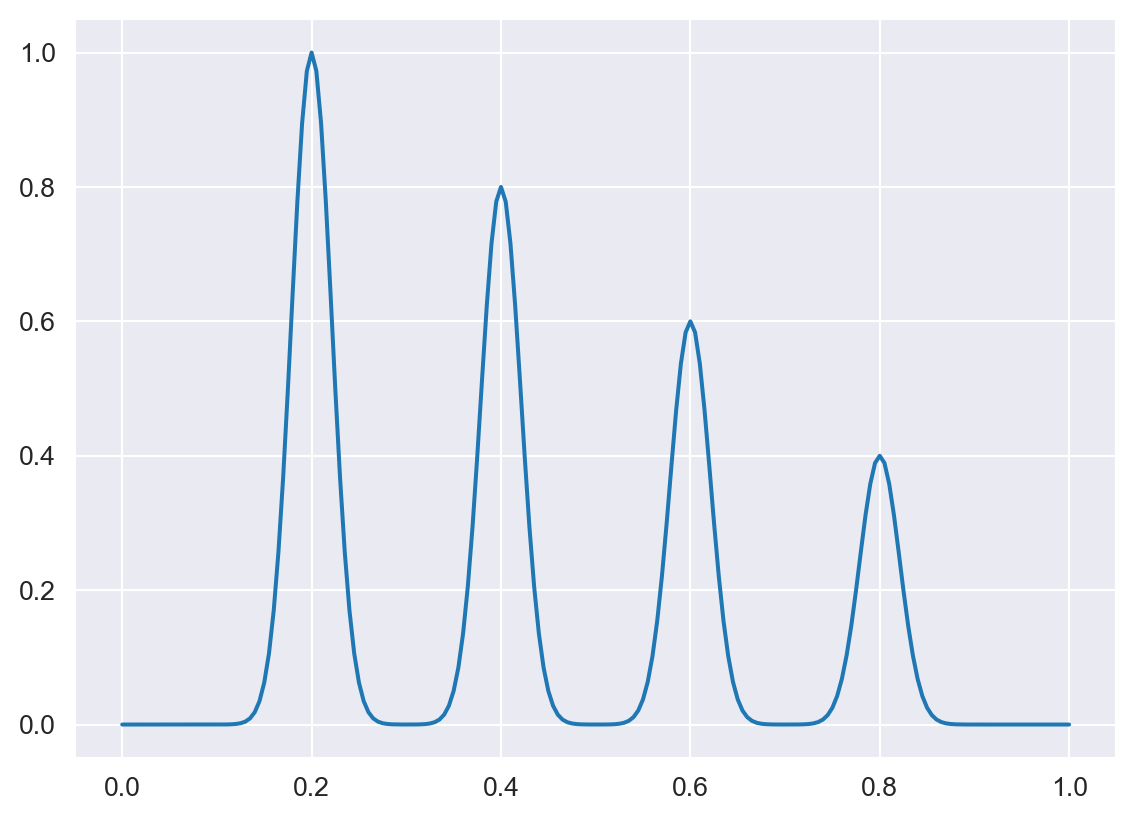

In [12]:
g = lambda t, args: (
    t_funcs.gaussian(1)(t, args)
    + t_funcs.gaussian(2)(t, args)
    + t_funcs.gaussian(3)(t, args)
    + t_funcs.gaussian(4)(t, args)
)
plt.plot(
    tlist,
    g(
        tlist,
        args={
            "ampl_1": 1.0,
            "fwhm_1": 0.05,
            "centre_1": 0.2,
            "ampl_2": 0.8,
            "fwhm_2": 0.05,
            "centre_2": 0.4,
            "ampl_3": 0.6,
            "fwhm_3": 0.05,
            "centre_3": 0.6,
            "ampl_4": 0.4,
            "fwhm_4": 0.05,
            "centre_4": 0.8,
        },
    ),
);